# Design and Implement Q-Learning Algorithm for Reinforcement Learning
This practical is different from the earlier ones — it doesn't use the student marks dataset, since Q-Learning needs an **environment** an agent can interact with (states, actions, rewards), not a static table of labeled data.

The environment here is a simple **5x5 grid world**: an agent starts at the top-left corner and must learn, purely through trial and error and rewards, the best path to reach a goal at the bottom-right corner while avoiding an obstacle cell.

#### 1. Define the environment (Grid World)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

GRID_SIZE = 5
START_STATE = (0, 0)
GOAL_STATE = (4, 4)
OBSTACLE_STATE = (2, 2)

ACTIONS = ['UP', 'DOWN', 'LEFT', 'RIGHT']
ACTION_EFFECTS = {
    'UP': (-1, 0),
    'DOWN': (1, 0),
    'LEFT': (0, -1),
    'RIGHT': (0, 1)
}

def get_reward(state):
    if state == GOAL_STATE:
        return 10
    if state == OBSTACLE_STATE:
        return -5
    return -1  # small penalty per step, encourages the agent to find the shortest path

def next_state(state, action):
    row, col = state
    d_row, d_col = ACTION_EFFECTS[action]
    new_row = min(max(row + d_row, 0), GRID_SIZE - 1)
    new_col = min(max(col + d_col, 0), GRID_SIZE - 1)
    return (new_row, new_col)#### 1. Define the environment (Grid World)

#### 2. Initialize the Q-table

In [2]:
# One row per state (grid cell), one column per possible action, all starting at 0
q_table = np.zeros((GRID_SIZE, GRID_SIZE, len(ACTIONS)))

print("Q-table shape:", q_table.shape)

Q-table shape: (5, 5, 4)


#### 3. Set Q-Learning hyperparameters
- **alpha** (learning rate): how much new information overrides old Q-values
- **gamma** (discount factor): how much future rewards matter versus immediate rewards
- **epsilon** (exploration rate): probability of taking a random action instead of the best known one, decayed over time so the agent explores early and exploits what it has learned later

In [4]:
alpha = 0.1
gamma = 0.9
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995

num_episodes = 500
max_steps_per_episode = 100

#### 4. Train the agent using Q-Learning
For each episode, the agent starts fresh at `START_STATE` and takes actions until it reaches the goal or runs out of steps. After every action, the Q-value for that state-action pair is updated using the Bellman equation:

`Q(s, a) = Q(s, a) + alpha * [reward + gamma * max(Q(s', a')) - Q(s, a)]`

In [5]:
rewards_per_episode = []

for episode in range(num_episodes):
    state = START_STATE
    total_reward = 0

    for step in range(max_steps_per_episode):
        # epsilon-greedy action selection: explore randomly, or exploit the best known action
        if np.random.rand() < epsilon:
            action_index = np.random.randint(len(ACTIONS))
        else:
            action_index = np.argmax(q_table[state[0], state[1]])

        action = ACTIONS[action_index]
        new_state = next_state(state, action)
        reward = get_reward(new_state)
        total_reward += reward

        # Bellman equation update
        best_next_q = np.max(q_table[new_state[0], new_state[1]])
        current_q = q_table[state[0], state[1], action_index]
        q_table[state[0], state[1], action_index] = current_q + alpha * (reward + gamma * best_next_q - current_q)

        state = new_state

        if state == GOAL_STATE:
            break

    # decay epsilon so the agent explores less as it learns more
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    rewards_per_episode.append(total_reward)

print("Training complete.")
print(f"Average reward over last 50 episodes: {np.mean(rewards_per_episode[-50:]):.2f}")

Training complete.
Average reward over last 50 episodes: 1.84


#### 5. Plot reward progression over episodes

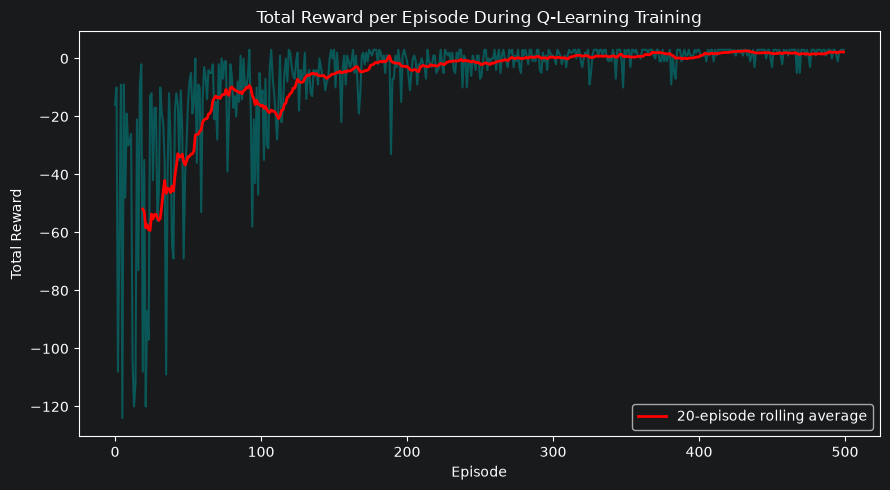

In [6]:
plt.figure(figsize=(9, 5))
plt.plot(rewards_per_episode, color='teal', alpha=0.6)

# rolling average makes the learning trend much easier to see through the episode-to-episode noise
window = 20
if len(rewards_per_episode) >= window:
    rolling_avg = np.convolve(rewards_per_episode, np.ones(window) / window, mode='valid')
    plt.plot(range(window - 1, len(rewards_per_episode)), rolling_avg, color='red', linewidth=2, label=f'{window}-episode rolling average')

plt.title('Total Reward per Episode During Q-Learning Training')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.legend()
plt.tight_layout()
plt.show()

#### 6. Extract the learned optimal policy
For each state, the best action is simply the one with the highest Q-value.

In [7]:
policy_symbols = {'UP': '↑', 'DOWN': '↓', 'LEFT': '←', 'RIGHT': '→'}

print("Learned policy (best action per cell):\n")
for row in range(GRID_SIZE):
    row_display = []
    for col in range(GRID_SIZE):
        cell = (row, col)
        if cell == GOAL_STATE:
            row_display.append(' G ')
        elif cell == OBSTACLE_STATE:
            row_display.append(' X ')
        else:
            best_action = ACTIONS[np.argmax(q_table[row, col])]
            row_display.append(f' {policy_symbols[best_action]} ')
    print(''.join(row_display))

Learned policy (best action per cell):

 →  ↓  ↓  ↓  ↓ 
 →  →  →  ↓  ↓ 
 →  ↓  X  →  ↓ 
 →  →  →  →  ↓ 
 →  →  →  →  G 


#### 7. Visualize the learned policy on the grid

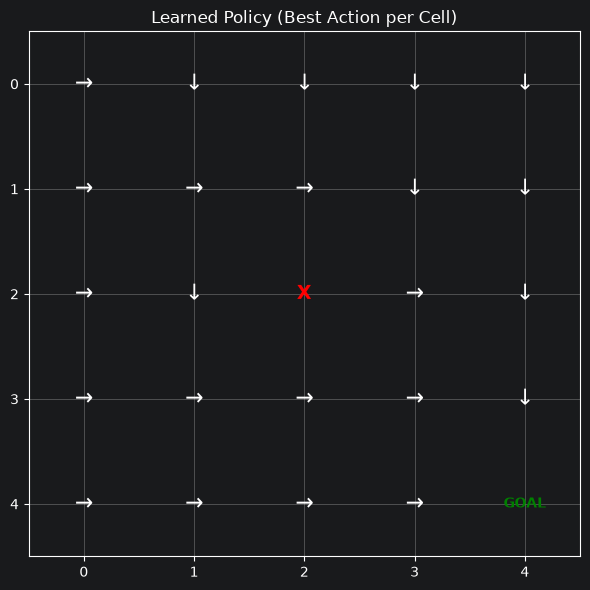

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))

for row in range(GRID_SIZE):
    for col in range(GRID_SIZE):
        cell = (row, col)
        if cell == GOAL_STATE:
            ax.text(col, row, 'GOAL', ha='center', va='center', color='green', fontweight='bold')
        elif cell == OBSTACLE_STATE:
            ax.text(col, row, 'X', ha='center', va='center', color='red', fontweight='bold', fontsize=14)
        else:
            best_action = ACTIONS[np.argmax(q_table[row, col])]
            ax.text(col, row, policy_symbols[best_action], ha='center', va='center', fontsize=16)

ax.set_xlim(-0.5, GRID_SIZE - 0.5)
ax.set_ylim(GRID_SIZE - 0.5, -0.5)  # flip y-axis so row 0 is at the top, like a normal grid
ax.set_xticks(range(GRID_SIZE))
ax.set_yticks(range(GRID_SIZE))
ax.grid(True)
ax.set_title('Learned Policy (Best Action per Cell)')
plt.tight_layout()
plt.show()

#### 8. Test the trained agent (greedy run, no exploration)
Follow the learned policy step by step from the start state to see the actual path taken.

In [9]:
state = START_STATE
path = [state]

for step in range(max_steps_per_episode):
    action_index = np.argmax(q_table[state[0], state[1]])  # always pick the best action now, no randomness
    action = ACTIONS[action_index]
    state = next_state(state, action)
    path.append(state)

    if state == GOAL_STATE:
        break

print(f"Path taken ({len(path) - 1} steps):")
print(' -> '.join(str(s) for s in path))

Path taken (8 steps):
(0, 0) -> (0, 1) -> (1, 1) -> (1, 2) -> (1, 3) -> (2, 3) -> (2, 4) -> (3, 4) -> (4, 4)
